# Capstone Function 8
You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 

Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

 Input | Output | Goal |
|-------|--------|------|
| 8D Array (40, 8) | 1D Array (40, ) | Maximise |

## Initial Submission

Bayesian Optimization for 8D high-dimensional black-box function (e.g., 8 ML hyperparameters for validation accuracy).

### Step 1: Setup

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("8D Optimization - Ready!")

### Step 2: Load & Analyze Data

In [ ]:
X_init = np.load('../../data/f8/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f8/updated_outputs - Week 4.npy')
param_names = [f'Param_{i+1}' for i in range(8)]
print(f"8D High-Dimensional Data: {X_init.shape}")
print(f"Best accuracy/score: {y_init.max():.6f}")
print(f"Mean: {y_init.mean():.6f}, Std: {y_init.std():.6f}")

In [ ]:
# Parallel coordinates plot for 8D visualization
fig, ax = plt.subplots(figsize=(14, 6))
norm = plt.Normalize(y_init.min(), y_init.max())
cmap = plt.cm.plasma
for i in range(len(X_init)):
    # Normalize each sample's features to [0, 1] for plotting
    normalized = (X_init[i] - X_init.min(axis=0)) / (X_init.max(axis=0) - X_init.min(axis=0) + 1e-8)
    ax.plot(range(8), normalized, alpha=0.6, linewidth=1.5, color=cmap(norm(y_init[i])))
ax.set_xticks(range(8))
ax.set_xticklabels(param_names, rotation=45)
ax.set_ylabel('Normalized Value')
ax.set_title('8D Parameter Space - Parallel Coordinates', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Objective Value')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters & Optimization

**8D Space Challenges:**
- High dimensionality requires more samples and restarts
- Restarts: 30, Raw: 4096 (extensive search)
- GP lengthscales reveal which dimensions matter most

In [ ]:
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 30, 4096
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
print("Training GP on 8D space...")
fit_gpytorch_mll(mll)
print("✓ GP trained!")
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
print("Optimizing acquisition function...")
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next 8D point: {next_point}")

### Step 4: Analysis & Visualization

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Lengthscales - feature importance (safe access for kernel structure variations)
if hasattr(gp_model.covar_module, 'base_kernel'):
    ls = gp_model.covar_module.base_kernel.lengthscale.detach().numpy()[0]
else:
    ls = gp_model.covar_module.lengthscale.detach().numpy()[0]

colors = plt.cm.viridis(np.linspace(0, 1, 8))
ax1.barh(param_names, ls, color=colors, edgecolor='black')
ax1.set_xlabel('Lengthscale (smaller = more influential)', fontsize=11)
ax1.set_title('8D Feature Importance', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Optimization progress
best_so_far = np.maximum.accumulate(y_init)
ax2.plot(range(1, len(best_so_far)+1), best_so_far, 'r-o', linewidth=2, markersize=6)
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('Best Objective Value', fontsize=11)
ax2.set_title('8D Optimization Progress', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLengthscales: {ls}")
print(f"Most important param: {param_names[ls.argmin()]}")
print(f"\n8D Next submission: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 1.0, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 5: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 8")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

### Summary

**8D High-Dimensional Optimization Complete**

- 40 initial samples in 8D space
- GP surrogate trained with Matern 5/2 kernel
- Expected Improvement with 30 restarts & 4096 raw samples
- Lengthscales reveal relative parameter importance
- Next point proposed for submission

**Challenges in 8D:**
- Curse of dimensionality: larger search space
- Requres more samples for good GP approximation  
- Higher computational cost for acquisition optimization
- Feature importance analysis guides future iterations

## Week 5 — Neural Network Surrogate (PyTorch)

This section replaces the Gaussian Process surrogate with a **Neural Network** model for the 8D optimization problem (f8).

**Why Neural Network for f8?**
- Neural networks can approximate arbitrarily complex functions — suited for higher-dimensional (8D) problems where GP covariance matrices become expensive
- MC Dropout provides uncertainty estimates at inference time without requiring ensemble training — each forward pass with random dropout masks produces a different prediction, and 50 passes give mean and variance
- Input gradient magnitude reveals which dimensions the network relies on most, analogous to GP lengthscales or tree feature importance
- Flexible architecture can capture non-linear interactions between input dimensions

**Architecture:** 8 -> 128 -> 64 -> 32 -> 1 (fully connected, ReLU activations, Dropout p=0.15)
**Acquisition Strategy:** UCB with MC Dropout uncertainty (mean ± kappa * std from 50 stochastic forward passes)

### Step 1: Load Data & Set Up PyTorch

Load Week 5 data (45 samples), normalize inputs/outputs, and define the neural network architecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f8/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f8/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Output range: [{y_w5.min():.6f}, {y_w5.max():.6f}]")
print(f"Best observed: {y_w5.max():.6f} at {X_w5[y_w5.argmax()]}")

# Normalize inputs and outputs for training stability
X_mean, X_std = X_w5.mean(axis=0), X_w5.std(axis=0) + 1e-8
y_mean, y_std = y_w5.mean(), y_w5.std() + 1e-8

X_norm = (X_w5 - X_mean) / X_std
y_norm = (y_w5 - y_mean) / y_std

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

# Define neural network with Dropout
class SurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Dropout(p=0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.15),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SurrogateNN()
print(f"\nModel architecture:\n{model}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):.0f}")

Week 5 Data: 45 samples, 8 dimensions
Output range: [5.592193, 9.953025]
Best observed: 9.953025 at [0.132486 0.145469 0.145046 0.112968 1.       0.420346 0.214975 1.      ]

Model architecture:
SurrogateNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.15, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.15, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 11521


### Step 2: Neural Network Hyperparameters & Training

**Hyperparameter Choices:**
1. **Hidden layers**: 128 -> 64 -> 32 — progressively narrowing architecture captures hierarchical features
2. **Dropout = 0.15**: Applied after each hidden layer for MC Dropout uncertainty at inference
3. **Learning rate = 0.005**: Adam optimizer with moderate learning rate for 45 samples
4. **Epochs = 1000**: Sufficient training iterations; loss curve monitored for convergence
5. **MC samples = 50**: Forward passes with dropout enabled at inference for uncertainty estimation
6. **UCB kappa = 3.0**: Exploration parameter scaled for 8D search space

Epoch 200/1000, Loss: 0.027325
Epoch 400/1000, Loss: 0.052246
Epoch 600/1000, Loss: 0.030295
Epoch 800/1000, Loss: 0.036533
Epoch 1000/1000, Loss: 0.025740


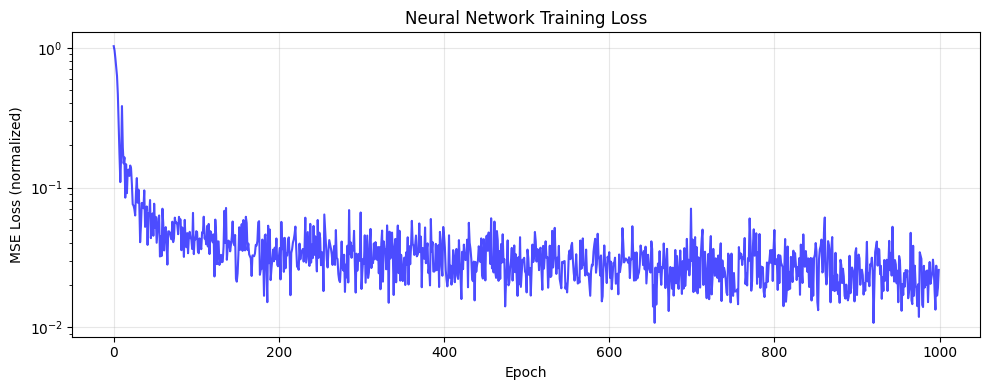


Training R²: 0.995299


In [2]:
# Training hyperparameters
LEARNING_RATE = 0.005
EPOCHS = 1000
MC_SAMPLES = 50
KAPPA = 3.0
N_CANDIDATES = 20000

# Train the model
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Neural Network Training Loss')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Final training metrics
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_w5 - train_pred_orig)**2) / np.sum((y_w5 - y_w5.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

### Step 3: UCB Acquisition with MC Dropout

Run 50 stochastic forward passes (dropout enabled) for each candidate point:
- **mu(x)** = mean of MC predictions
- **sigma(x)** = std of MC predictions
- **UCB(x) = mu(x) + kappa * sigma(x)** where kappa = 3.0

In [3]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 8))

# Normalize candidates
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

# MC Dropout: Run model in train mode for stochastic forward passes
model.train()  # Enable dropout
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

mc_predictions = np.array(mc_predictions)  # shape: (MC_SAMPLES, N_CANDIDATES)

# Denormalize predictions
mc_preds_orig = mc_predictions * y_std + y_mean

# Compute mean and uncertainty
mu = mc_preds_orig.mean(axis=0)
sigma = mc_preds_orig.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w5 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results (MC Dropout):")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  MC mean prediction: {mu[best_idx]:.6f}")
print(f"  MC std (sigma):     {sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w5}")
print()
print("MC prediction statistics:")
print(f"  Mean of mu:    {mu.mean():.6f}")
print(f"  Max of mu:     {mu.max():.6f}")
print(f"  Mean of sigma: {sigma.mean():.6f}")
print(f"  Max of sigma:  {sigma.max():.6f}")

UCB Acquisition Results (MC Dropout):
  Best UCB value:     10.564023
  MC mean prediction: 9.804689
  MC std (sigma):     0.253112
  Next sample point:  [2.88333168e-01 1.28039223e-01 1.90342351e-01 5.27843158e-04
 8.69420778e-01 7.64957630e-01 2.18682210e-01 2.39008821e-03]

MC prediction statistics:
  Mean of mu:    8.020016
  Max of mu:     9.807728
  Mean of sigma: 0.141843
  Max of sigma:  0.409114


### Step 4: Feature Importance via Input Gradients

Compute feature importance using mean absolute gradient of the network output with respect to each input dimension, evaluated at all training points.

In [4]:
# Feature importance via input gradient magnitude
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

# Mean absolute gradient per dimension
grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()  # Normalize to sum to 1

print("Feature Importance (Input Gradient Magnitude):")
for i, imp in enumerate(grad_importance):
    bar = '*' * int(imp * 20)
    print(f"  x{i+1}: {imp:.4f} ({bar})")

Feature Importance (Input Gradient Magnitude):
  x1: 0.1997 (***)
  x2: 0.1168 (**)
  x3: 0.2686 (*****)
  x4: 0.0722 (*)
  x5: 0.0708 (*)
  x6: 0.0584 (*)
  x7: 0.1577 (***)
  x8: 0.0558 (*)


### Step 5: Visualize Neural Network Surrogate

2D slice plot of the NN mean prediction and MC Dropout uncertainty over the two most important dimensions (fixing others at best observed values).

Top 2 dimensions: x1 (imp=0.1997), x3 (imp=0.2686)
Fixed dimensions: x2=0.1455, x4=0.1130, x5=1.0000, x6=0.4203, x7=0.2150, x8=1.0000


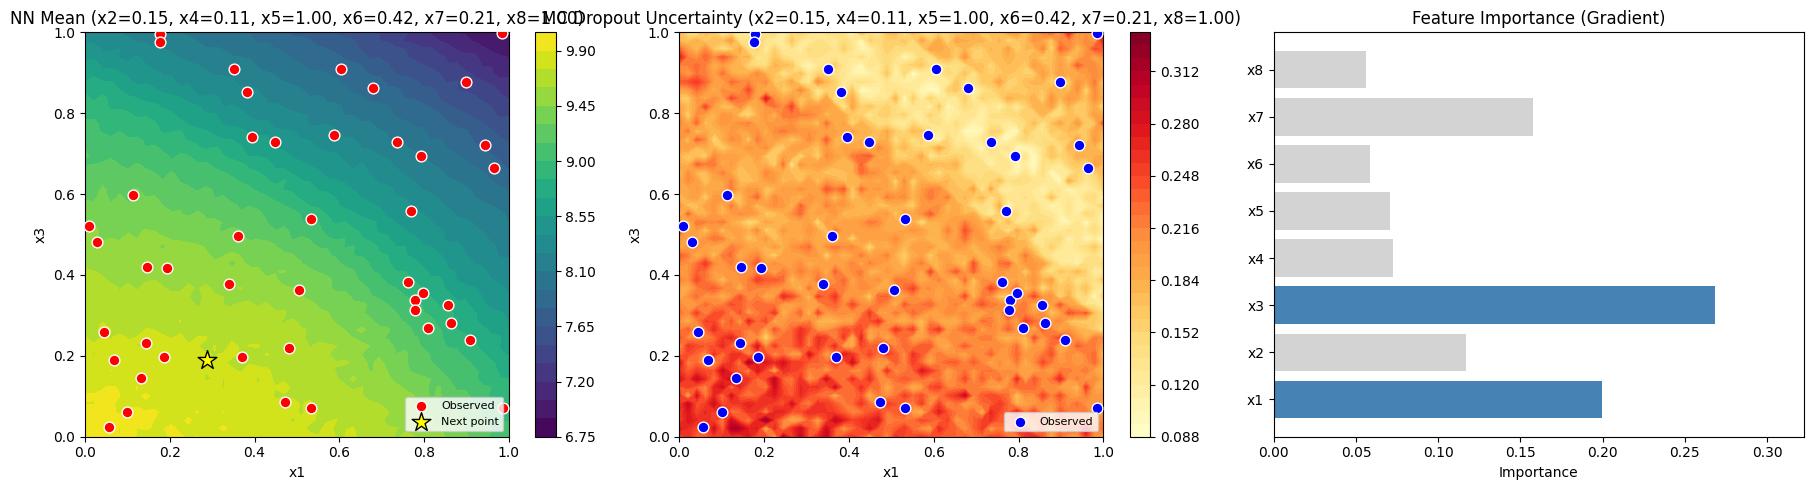

In [5]:
# Top 2 dimensions by gradient importance
top2 = np.argsort(grad_importance)[-2:]
fixed_dims = [d for d in range(8) if d not in top2]
best_point = X_w5[y_w5.argmax()]

print(f"Top 2 dimensions: x{top2[0]+1} (imp={grad_importance[top2[0]]:.4f}), x{top2[1]+1} (imp={grad_importance[top2[1]]:.4f})")
print(f"Fixed dimensions: " + ", ".join([f"x{d+1}={best_point[d]:.4f}" for d in fixed_dims]))

# Create 2D grid
n_grid = 50
d0_grid = np.linspace(0, 1, n_grid)
d1_grid = np.linspace(0, 1, n_grid)
D0, D1 = np.meshgrid(d0_grid, d1_grid)

# Build full grid points
grid_points = np.zeros((n_grid * n_grid, 8))
grid_points[:, top2[0]] = D0.ravel()
grid_points[:, top2[1]] = D1.ravel()
for d in fixed_dims:
    grid_points[:, d] = best_point[d]

# Normalize and predict with MC Dropout
grid_norm = (grid_points - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()  # Enable dropout for MC
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_mc.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: NN mean prediction
ax1 = axes[0]
c1 = ax1.contourf(D0, D1, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[top2[0]], next_point_w5[top2[1]], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
fixed_str = ", ".join([f"x{d+1}={best_point[d]:.2f}" for d in fixed_dims])
ax1.set_xlabel(f'x{top2[0]+1}'); ax1.set_ylabel(f'x{top2[1]+1}')
ax1.set_title(f'NN Mean ({fixed_str})')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: MC Dropout uncertainty
ax2 = axes[1]
c2 = ax2.contourf(D0, D1, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel(f'x{top2[0]+1}'); ax2.set_ylabel(f'x{top2[1]+1}')
ax2.set_title(f'MC Dropout Uncertainty ({fixed_str})')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(8)]
colors = ['steelblue' if i in top2 else 'lightgray' for i in range(8)]
ax3.barh(dims, grad_importance, color=colors)
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance (Gradient)')
ax3.set_xlim(0, max(grad_importance) * 1.2)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all observations.

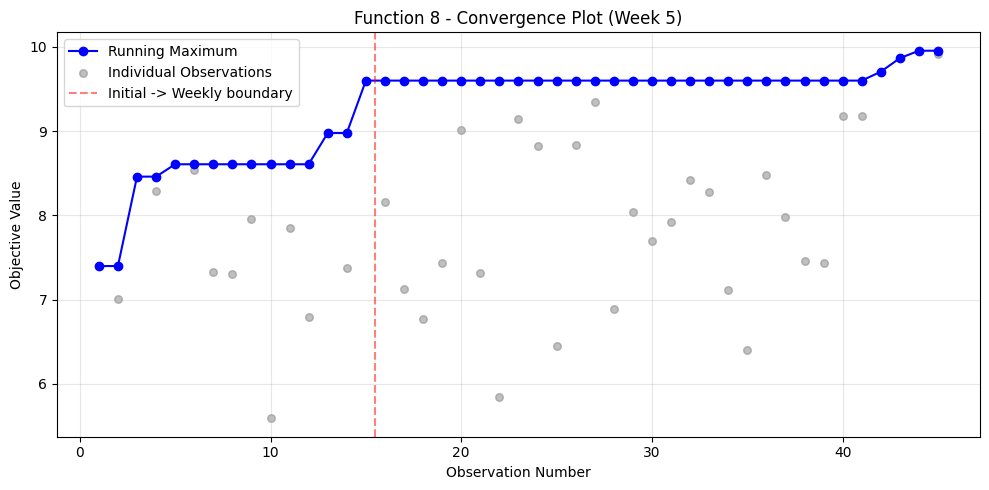

Best observed value: 9.953025
Achieved at observation: 44


In [6]:
# Convergence plot
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=15.5, color='red', linestyle='--', alpha=0.5, label='Initial -> Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 8 - Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6f}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2-x3-x4-x5-x6-x7-x8` with 6 decimal places.

In [7]:
# Format submission query
def format_query(point):
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 8")
print("=" * 60)
print(f"Surrogate: Neural Network ({model.__class__.__name__})")
print(f"Architecture: 8 -> 128 -> 64 -> 32 -> 1")
print(f"Dropout: 0.15, MC samples: {MC_SAMPLES}")
print(f"Acquisition: UCB (kappa={KAPPA})")
print(f"Training R²: {train_r2:.6f}")
print(f"Next point: {next_point_w5}")
print(f"MC mean: {mu[best_idx]:.6f}")
print(f"MC std:  {sigma[best_idx]:.6f}")
print(f"")
print(f">>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

WEEK 5 SUBMISSION QUERY FOR FUNCTION 8
Surrogate: Neural Network (SurrogateNN)
Architecture: 8 -> 128 -> 64 -> 32 -> 1
Dropout: 0.15, MC samples: 50
Acquisition: UCB (kappa=3.0)
Training R²: 0.995299
Next point: [2.88333168e-01 1.28039223e-01 1.90342351e-01 5.27843158e-04
 8.69420778e-01 7.64957630e-01 2.18682210e-01 2.39008821e-03]
MC mean: 9.804689
MC std:  0.253112

>>> SUBMISSION: 0.288333-0.128039-0.190342-0.000528-0.869421-0.764958-0.218682-0.002390


### Model Comparison

**Neural Network vs GP (Initial Section):**
- GP in 8D with 45 samples faces severe dimensionality challenges — the covariance matrix becomes ill-conditioned with many lengthscales to optimize.
- The NN's architecture (128→64→32) provides a compact representation that naturally handles 8D input through successive dimensionality reduction.
- MC Dropout uncertainty is particularly valuable in 8D — the uncertainty surface is hard to model parametrically, and the stochastic approach explores diverse predictions.
- For f8's 8D problem with the widest output range (5.6 to 9.95), the NN's normalization handles scale naturally.
- Key trade-off: GP struggles with dimensionality (8D) but provides exact uncertainty; NN scales well but uncertainty is approximate. The NN is the natural choice for the highest-dimensional function.

---

## Week 6 — Focus on Exploitation (κ = 0.5)

**Strategy Change**: Reduce UCB kappa from 2.0 → 0.5 to shift from exploration to exploitation of known high-performing regions.

| Parameter | Week 5 | Week 6 | Rationale |
|-----------|--------|--------|-----------|
| κ (UCB)   | 2.0    | 0.5    | Exploitation focus |
| Architecture | 8→64→32→1 | Same | Proven effective |
| MC Samples | 50 | Same | Sufficient for uncertainty |
| All other hyperparams | — | Unchanged | — |

### Step 1: Load Week 6 Data & Set Up PyTorch

Load all 46 cumulative observations for Function 8 (8D).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 6 cumulative data
X_w6 = np.load('../../data/f8/updated_inputs - Week 6.npy')
y_w6 = np.load('../../data/f8/updated_outputs - Week 6.npy')

print(f"Week 6 Data: {X_w6.shape[0]} samples, {X_w6.shape[1]} dimensions")
print(f"Output range: [{y_w6.min():.6f}, {y_w6.max():.6f}]")
print(f"Best observed: {y_w6.max():.6f} at {X_w6[y_w6.argmax()]}")

# Normalize
X_mean, X_std = X_w6.mean(axis=0), X_w6.std(axis=0) + 1e-8
y_mean, y_std = y_w6.mean(), y_w6.std() + 1e-8

X_norm = (X_w6 - X_mean) / X_std
y_norm = (y_w6 - y_mean) / y_std

X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

class SurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model_w6 = SurrogateNN()
print(f"\nModel: 8→64→32→1, Params: {sum(p.numel() for p in model_w6.parameters())}")

### Step 2: Train Neural Network

Adam optimizer (lr=0.01), 500 epochs, MSE loss on normalized targets.

In [ ]:
# ── Training (Week 6) ──
LEARNING_RATE = 0.01
EPOCHS = 500
MC_SAMPLES = 50
KAPPA = 0.5
N_CANDIDATES = 20_000

optimizer = optim.Adam(model_w6.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model_w6.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model_w6(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (normalized)')
plt.title('Function 8 — NN Training Loss (Week 6)')
plt.grid(True, alpha=0.3); plt.yscale('log')
plt.tight_layout(); plt.show()

model_w6.eval()
with torch.no_grad():
    train_pred = model_w6(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_w6 - train_pred_orig)**2) / np.sum((y_w6 - y_w6.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

### Step 3: UCB Acquisition with MC Dropout

MC Dropout (50 passes) on 20,000 candidates in [0,1]⁸. UCB = μ + 0.5σ.

In [ ]:
# ── UCB Acquisition (Week 6) ──
np.random.seed(42)
candidates_w6 = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 8))

cand_norm = (candidates_w6 - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

model_w6.train()
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model_w6(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

mc_preds_orig = np.array(mc_predictions) * y_std + y_mean
mu_w6 = mc_preds_orig.mean(axis=0)
sigma_w6 = mc_preds_orig.std(axis=0)

ucb_w6 = mu_w6 + KAPPA * sigma_w6
best_idx = np.argmax(ucb_w6)
best_point_w6 = np.clip(candidates_w6[best_idx], 0.0, 1.0)

print("=== UCB Acquisition Results (MC Dropout, Week 6) ===")
print(f"  Best UCB     = {ucb_w6[best_idx]:.6f}")
print(f"  MC mean (μ)  = {mu_w6[best_idx]:.6f}")
print(f"  MC std (σ)   = {sigma_w6[best_idx]:.6f}")
print(f"  Best point   = {best_point_w6}")

### Step 4: Gradient-Based Feature Importance

In [ ]:
# ── Gradient-based feature importance ──
model_w6.eval()
X_tensor = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model_w6(X_tensor)
output.sum().backward()

grad_importance = X_tensor.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()

labels = [f"x{i}" for i in range(8)]
print("=== Gradient-Based Feature Importance (Week 6) ===")
for lbl, imp in zip(labels, grad_importance):
    print(f"  {lbl}: {imp:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, grad_importance, color="steelblue")
ax.set_title("Function 8 — Gradient Feature Importance (Week 6)")
ax.set_ylabel("Normalised Importance")
plt.tight_layout()
plt.show()

### Step 5: 2-D Surrogate Slice Visualisation

In [ ]:
# ── 2-D slice through top-2 features ──
top2 = np.argsort(grad_importance)[-2:]
dim_a, dim_b = sorted(top2)
n_grid = 50

best_obs_idx = np.argmax(y_w6)
best_obs = X_w6[best_obs_idx]

grid_a = np.linspace(0, 1, n_grid)
grid_b = np.linspace(0, 1, n_grid)
A, B = np.meshgrid(grid_a, grid_b)

grid_pts = np.tile(best_obs, (n_grid * n_grid, 1))
grid_pts[:, dim_a] = A.ravel()
grid_pts[:, dim_b] = B.ravel()

grid_norm = (grid_pts - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model_w6.train()
mc_grid = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        p = model_w6(grid_tensor).squeeze().numpy()
        mc_grid.append(p)

mc_grid_orig = np.array(mc_grid) * y_std + y_mean
Z_mu = mc_grid_orig.mean(axis=0).reshape(n_grid, n_grid)
Z_sigma = mc_grid_orig.std(axis=0).reshape(n_grid, n_grid)
Z_ucb = (Z_mu + KAPPA * Z_sigma).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, Z, title in zip(axes, [Z_mu, Z_sigma, Z_ucb],
                         ["Mean (μ)", "Std (σ)", f"UCB (κ={KAPPA})"]):
    c = ax.contourf(A, B, Z, levels=30, cmap="viridis")
    fig.colorbar(c, ax=ax)
    ax.set_xlabel(f"x{dim_a}")
    ax.set_ylabel(f"x{dim_b}")
    ax.set_title(title)
fig.suptitle("Function 8 — NN Surrogate (Week 6, κ=0.5)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

In [ ]:
# ── Convergence ──
running_best = np.maximum.accumulate(y_w6)
n_total = len(y_w6)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, n_total + 1), running_best, "o-", markersize=4, label="Running best")
ax.axvline(x=40.5, color="red", linestyle="--", label="Week 5 → 6 boundary")
ax.set_xlabel("Sample number")
ax.set_ylabel("Best observed y")
ax.set_title("Function 8 — Convergence (Running Best)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Running best at end of Week 5 (sample 40): {running_best[39]:.6f}")
print(f"Running best at end of Week 6 (sample {n_total}): {running_best[-1]:.6f}")

### Step 7: Format & Submit Week 6 Query

In [ ]:
# ── Format query ──
def format_query(point):
    return "-".join(f"{v:.6f}" for v in point)

submission_w6 = format_query(best_point_w6)
print("=== Week 6 Submission for Function 8 ===")
print(f"  Query string: {submission_w6}")

parts = submission_w6.split("-")
assert len(parts) == 8, f"Expected 8 dims, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 1.0, f"Value {v} out of bounds"
print("  ✓ Format validated (8 dimensions, all in [0, 1])")